### Notebook used to visualize the generated datasets

In [2]:
%cd C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM

C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


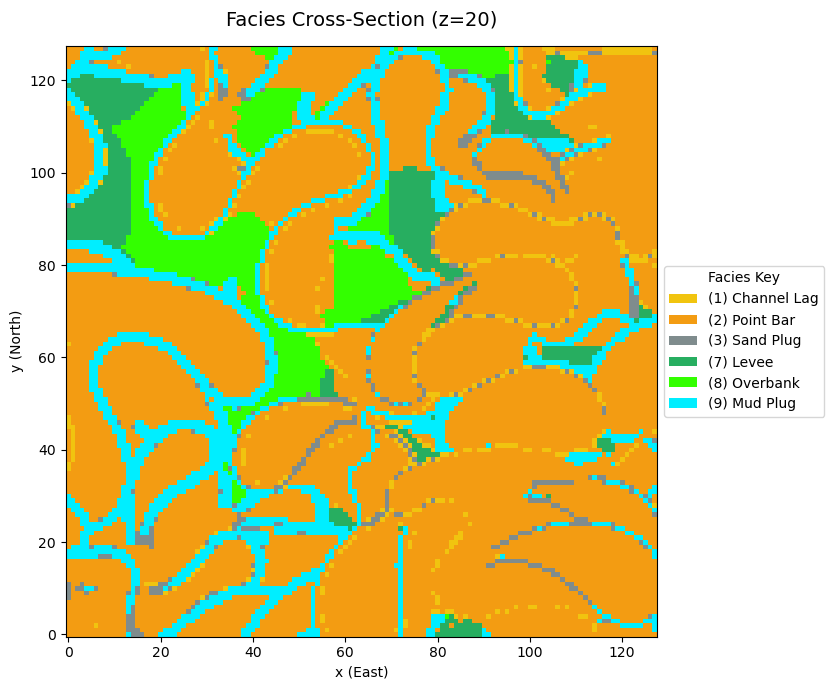

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# --- 1. Define Facies Properties ---
facies_properties = {
    'undefined':           {'val': 0,  'color': "#ae00ff", 'grain_size': 0,  'porosity_class': 0,    'description': "Background/Undefined"},
    'channel_lag':         {'val': 1,  'color': "#f1c40f", 'grain_size': 13, 'porosity_class': -2,   'description': "Active channel fill, coarse-grained"},
    'point_bar':           {'val': 2,  'color': "#f39c12", 'grain_size': 10, 'porosity_class': 1,    'description': "Lower energy channel margins"},
    'sand_plug':           {'val': 3,  'color': "#7f8c8d", 'grain_size': 9,  'porosity_class': 2,    'description': "Fine-grained oxbow/plug fill"},
    'crevasse_splay_core': {'val': 4,  'color': "#e67e22", 'grain_size': 9,  'porosity_class': 2,    'description': "Proximal high-energy splay"},
    'crevasse_channel':    {'val': 5,  'color': "#8aff9e", 'grain_size': 8,  'porosity_class': 3,    'description': "Feeder channel for splays"},
    'crevasse_splay_delta':{'val': 6,  'color': "#a7c22f", 'grain_size': 7,  'porosity_class': 2,    'description': "Distal fan-like splay deposit"},
    'levee':               {'val': 7,  'color': "#27ae60", 'grain_size': 6,  'porosity_class': 5,    'description': "Sand/silt ridges bordering channel"},
    'overbank':            {'val': 8,  'color': "#33ff00", 'grain_size': 3,  'porosity_class': 8,    'description': "Stabilized/vegetated levee"},
    'mud_plug':            {'val': 9,  'color': "#00eeff", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Fine silts/clays far from channel"},
    'hemipelagic_plug':    {'val': 10, 'color': "#7a7d80", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Silts near active channel belts"},
    'wetland':             {'val': 11, 'color': "#d862f0", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Organic rich, very fine sediment"},
    'draping':             {'val': 12, 'color': "#8dd5e7", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lateral accretion sand bodies"},
    'pelagic':             {'val': 13, 'color': "#3498db", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lacustrine clay/silt"}
}

val_to_info = {
    info['val']: {
        'color': info['color'], 
        'name': key.replace('_', ' ').title() # Converts 'channel_lag' to 'Channel Lag'
    } 
    for key, info in facies_properties.items()
}

def visualize_facies_npz(file_path, slice_axis='y', slice_idx=None, is_one_hot=False):
    if not os.path.exists(file_path):
        print(f"Error: File {file_path} not found.")
        return

    # --- 2. Load and Preprocess ---
    data = np.load(file_path)
    fac_data = data['facies'] 

    if is_one_hot and fac_data.ndim == 4:
        fac_vol = np.argmax(fac_data, axis=0)
    else:
        fac_vol = fac_data[0] if fac_data.ndim == 4 else fac_data

    # --- 3. Map Colors and Labels ---
    unique_facies = np.sort(np.unique(fac_vol))
    
    current_colors = []
    current_labels = []
    
    for v in unique_facies:
        if v in val_to_info:
            current_colors.append(val_to_info[v]['color'])
            current_labels.append(f"{v}: {val_to_info[v]['name']}")
        else:
            # Fallback for unexpected values
            current_colors.append("#333333") 
            current_labels.append(f"{v}: Unknown")

    # --- 4. Slicing ---
    nz, ny, nx = fac_vol.shape
    if slice_axis == 'z':
        idx = slice_idx if slice_idx is not None else nz // 2
        slc = fac_vol[idx, :, :]
        ylabel, xlabel = "y (North)", "x (East)"
    elif slice_axis == 'y':
        idx = slice_idx if slice_idx is not None else ny // 2
        slc = fac_vol[:, idx, :]
        ylabel, xlabel = "z (Depth)", "x (East)"
    else:
        idx = slice_idx if slice_idx is not None else nx // 2
        slc = fac_vol[:, :, idx]
        ylabel, xlabel = "z (Depth)", "y (North)"

    # --- 5. Custom Colormap Setup ---
    cmap = ListedColormap(current_colors)
    # Norm ensures the color at index 'i' maps to unique_facies[i]
    norm = BoundaryNorm(np.append(unique_facies, unique_facies[-1] + 1) - 0.5, len(unique_facies))

    # --- 6. Plotting ---
    plt.figure(figsize=(14, 7))
    plt.imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='equal')
    
    # Generate legend only for facies present in the current slice
    vals_in_slice = np.unique(slc)
    legend_elements = []
    for v in vals_in_slice:
        color_idx = np.where(unique_facies == v)[0][0]
        label = val_to_info[v]['name'] if v in val_to_info else "Unknown"
        legend_elements.append(Patch(facecolor=current_colors[color_idx], label=f"({v}) {label}"))

    plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), 
               title="Facies Key", frameon=True)
    
    plt.title(f"Facies Cross-Section ({slice_axis}={idx})", fontsize=14, pad=15)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# --- Execution ---
base = os.path.join(os.getcwd(), "test_outputs")
visualize_facies_npz(os.path.join(base, "sample_43.npz"), slice_axis='z', slice_idx=20, is_one_hot=False)